# ch318 — LSTM and GRU

## 1. The problem with vanilla RNNs

As shown in ch317, gradients vanish over long sequences because $\partial h_t / \partial h_0$
involves repeated multiplication by $W_h$. The network cannot learn dependencies spanning
many time steps.

**Long Short-Term Memory** (Hochreiter & Schmidhuber, 1997) introduces a **cell state** $c_t$
that flows through time with only additive interactions — no repeated matrix multiplication —
allowing gradients to propagate over hundreds of steps.

---

## 2. LSTM equations

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{forget gate}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{input gate}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{output gate}$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c) \quad \text{candidate}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad \text{cell update}$$
$$h_t = o_t \odot \tanh(c_t)$$

The cell state $c_t$ is modified only by addition — the **constant error carousel** that
allows gradients to flow without decay over long sequences.

*(Sigmoid: ch309. Element-wise operations: ch123.)*

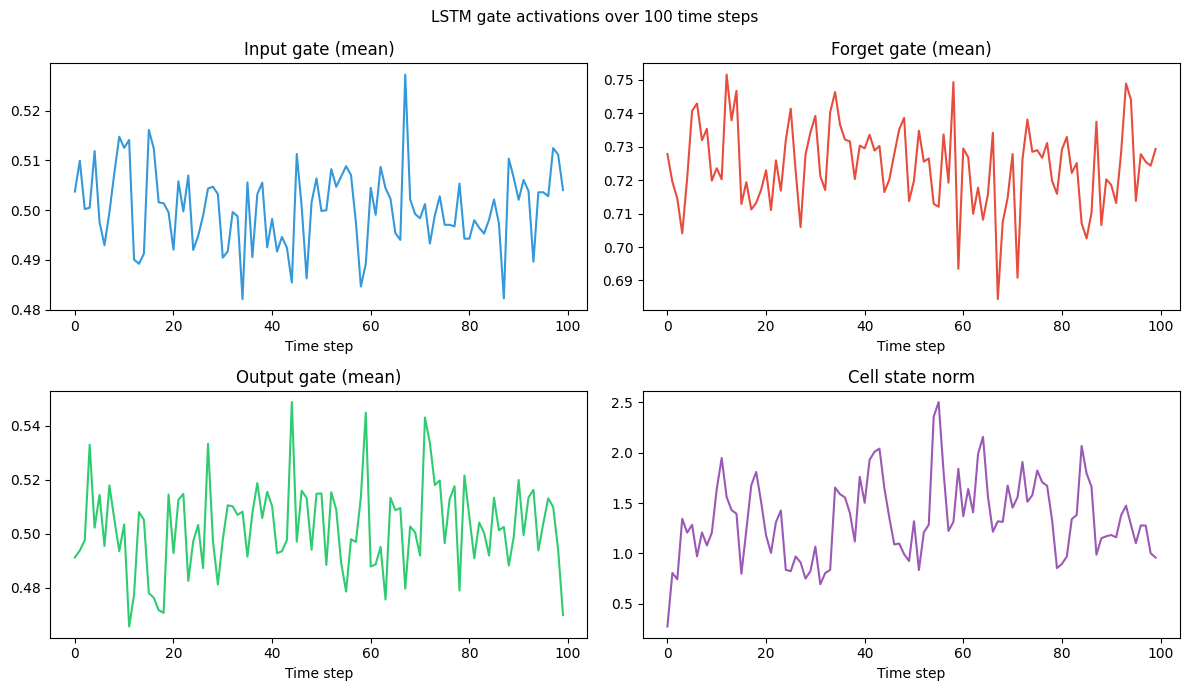

Parameter comparison (D=4, H=32):
  Vanilla RNN: 1,184
  GRU:         3,552
  LSTM:        4,736
  GRU/LSTM ratio: 0.75  (GRU is 75% the size)


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z): return 1/(1+np.exp(-np.clip(z,-500,500)))


class LSTMCell:
    """Single LSTM cell (unrolled for clarity)."""

    def __init__(self, input_dim: int, hidden_dim: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        H = hidden_dim; concat = input_dim + hidden_dim
        s = 1.0 / np.sqrt(concat)
        # All 4 gate weight matrices packed into one for efficiency
        self.W = rng.normal(0, s, (4 * H, concat))
        self.b = np.zeros(4 * H)
        # Initialise forget gate bias to 1 for better gradient flow
        self.b[H:2*H] = 1.0
        self.H = H

    def forward(self, x: np.ndarray, h_prev: np.ndarray,
                c_prev: np.ndarray) -> tuple:
        H = self.H
        xh = np.concatenate([x, h_prev])
        gates = self.W @ xh + self.b

        i = sigmoid(gates[:H])          # input gate
        f = sigmoid(gates[H:2*H])       # forget gate
        o = sigmoid(gates[2*H:3*H])     # output gate
        g = np.tanh(gates[3*H:])        # candidate

        c = f * c_prev + i * g          # cell state update (additive!)
        h = o * np.tanh(c)              # hidden state
        return h, c, (xh, i, f, o, g, c_prev, c)


class GRUCell:
    """Gated Recurrent Unit — simpler than LSTM, often comparable."""

    def __init__(self, input_dim: int, hidden_dim: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        H = hidden_dim; concat = input_dim + hidden_dim
        s = 1.0 / np.sqrt(concat)
        self.W_z = rng.normal(0, s, (H, concat))  # update gate
        self.W_r = rng.normal(0, s, (H, concat))  # reset gate
        self.W_h = rng.normal(0, s, (H, concat))  # candidate
        self.b_z = np.zeros(H); self.b_r = np.zeros(H); self.b_h = np.zeros(H)
        self.H = H

    def forward(self, x: np.ndarray, h_prev: np.ndarray) -> np.ndarray:
        xh = np.concatenate([x, h_prev])
        z = sigmoid(self.W_z @ xh + self.b_z)          # update gate
        r = sigmoid(self.W_r @ xh + self.b_r)          # reset gate
        xh_r = np.concatenate([x, r * h_prev])
        h_cand = np.tanh(self.W_h @ xh_r + self.b_h)  # candidate
        h = (1 - z) * h_prev + z * h_cand              # interpolate old/new
        return h


# ── Compare gradient flow: RNN vs LSTM ──
rng = np.random.default_rng(0)
T = 100; D = 4; H = 32

lstm = LSTMCell(D, H, seed=0)
x_seq = rng.normal(0, 1, (T, D))

# Track gate activations over time
h = np.zeros(H); c = np.zeros(H)
gate_log = {'i': [], 'f': [], 'o': [], 'g_norm': []}
for x in x_seq:
    h, c, (_, i, f, o, g, _, _) = lstm.forward(x, h, c)
    gate_log['i'].append(i.mean()); gate_log['f'].append(f.mean())
    gate_log['o'].append(o.mean()); gate_log['g_norm'].append(np.linalg.norm(c))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, key, color, label in zip(axes.ravel(),
        ['i','f','o','g_norm'],
        ['#3498db','#e74c3c','#2ecc71','#9b59b6'],
        ['Input gate (mean)', 'Forget gate (mean)', 'Output gate (mean)', 'Cell state norm']):
    ax.plot(gate_log[key], color=color, lw=1.5)
    ax.set_title(label); ax.set_xlabel('Time step')

plt.suptitle('LSTM gate activations over 100 time steps', fontsize=11)
plt.tight_layout()
plt.savefig('ch318_lstm_gates.png', dpi=120)
plt.show()

# Parameter count comparison
print("Parameter comparison (D=4, H=32):")
lstm_params = 4 * H * (D + H) + 4 * H
gru_params  = 3 * H * (D + H) + 3 * H
rnn_params  = H * (D + H) + H
print(f"  Vanilla RNN: {rnn_params:,}")
print(f"  GRU:         {gru_params:,}")
print(f"  LSTM:        {lstm_params:,}")
print(f"  GRU/LSTM ratio: {gru_params/lstm_params:.2f}  (GRU is 75% the size)")

## 3. Why the cell state solves vanishing gradients

The cell update rule $c_t = f_t \odot c_{t-1} + i_t \odot g_t$ is purely additive.
The gradient of the loss with respect to an old cell state $c_{t-k}$ is:

$$\frac{\partial c_t}{\partial c_{t-k}} = \prod_{j=t-k+1}^{t} f_j$$

This is a product of forget gate values — all in $(0, 1)$. But crucially, the forget
gate can learn to set $f \approx 1$ for dimensions that should be remembered, keeping
that gradient close to 1 over any number of steps.

## 4. Summary

- LSTM: input, forget, output gates + cell state. Additive cell update avoids vanishing gradients.
- Forget gate bias initialised to 1: encourages remembering by default at training start.
- GRU: update + reset gates, no separate cell state. Fewer parameters; similar performance.
- Both are standard seq-to-seq building blocks, now largely superseded by Transformers for NLP.

## 5. Forward and backward references

**Used here:** sigmoid *(ch309)*, tanh *(ch309)*, element-wise products *(ch123)*,
vanishing gradients *(ch317)*.

**This will reappear in ch319 — Sequence-to-Sequence Models**, where stacked LSTMs
form encoder-decoder architectures, and in ch336 — Project: Character-Level LM.